# Multivariate Analysis of Expected UK/US IRD (Proxied Using 2Y Bond Yield) Against GBP/USD

In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

## Load Data

In [3]:
# Load dtype map
dtype_map = pd.read_csv("../data/features/gbpusd/v1_11-09-25/gbpusd_features_dtypes_as_of_110925.csv").to_dict()

# Convert dtype strings to actual Python types
dtype_map = {
    col: eval(dtype_str) if "float" in dtype_str or "int" in dtype_str else "object"
    for col, dtype_str in dtype_map.items()
}

# Load cleaned data with correct types
gbpusd = pd.read_csv("../data/features/gbpusd/v1_11-09-25/gbpusd_features_as_of_110925.csv", dtype=dtype_map, parse_dates=[0], index_col=0)

In [4]:
gbpusd.head()

,gbp_usd_noon_rate,simple_return,log_return
date,,,
1971-01-04,2.3938,NaN,NaN
1971-01-05,2.3949,0.000460,0.000459
1971-01-06,2.3967,0.000752,0.000751
1971-01-07,2.3963,-0.000167,-0.000167
1971-01-08,2.3972,0.000376,0.000376


In [5]:
# Load dtype map
dtype_map = pd.read_csv("../data/features/spread/v1_11-09-25/spread_features_dtypes_as_of_110925.csv").to_dict()

# Convert dtype strings to actual Python types
dtype_map = {
    col: eval(dtype_str) if "float" in dtype_str or "int" in dtype_str else "object"
    for col, dtype_str in dtype_map.items()
}

# Load cleaned data with correct types
spread = pd.read_csv("../data/features/spread/v1_11-09-25/spread_features_as_of_110925.csv", dtype=dtype_map, parse_dates=[0], index_col=0)

In [6]:
spread.head()

,uk_2y,us_2y,spread_bp,spread_abs_change_daily,spread_bp_z_score,spread_abs_change_daily_z_score
date,,,,,,
1979-01-01,11.96,9.98,198.0,NaN,NaN,NaN
1979-01-02,11.96,10.00,196.0,-2.0,NaN,NaN
1979-01-03,11.99,9.98,201.0,5.0,NaN,NaN
1979-01-04,11.94,9.88,206.0,5.0,NaN,NaN
1979-01-05,11.89,9.87,202.0,-4.0,NaN,NaN


## Alignment

In [7]:
start = max(gbpusd.index.min(), spread.index.min())
end   = min(gbpusd.index.max(), spread.index.max())
calendar = pd.date_range(start=start, end=end, freq="B")

In [8]:
gbpusd = gbpusd.reindex(calendar)
spread = spread.reindex(calendar)

In [9]:
print(gbpusd["gbp_usd_noon_rate"].isna().sum())
print(spread["spread_bp"].isna().sum())

0
0


## Spread Time-Series

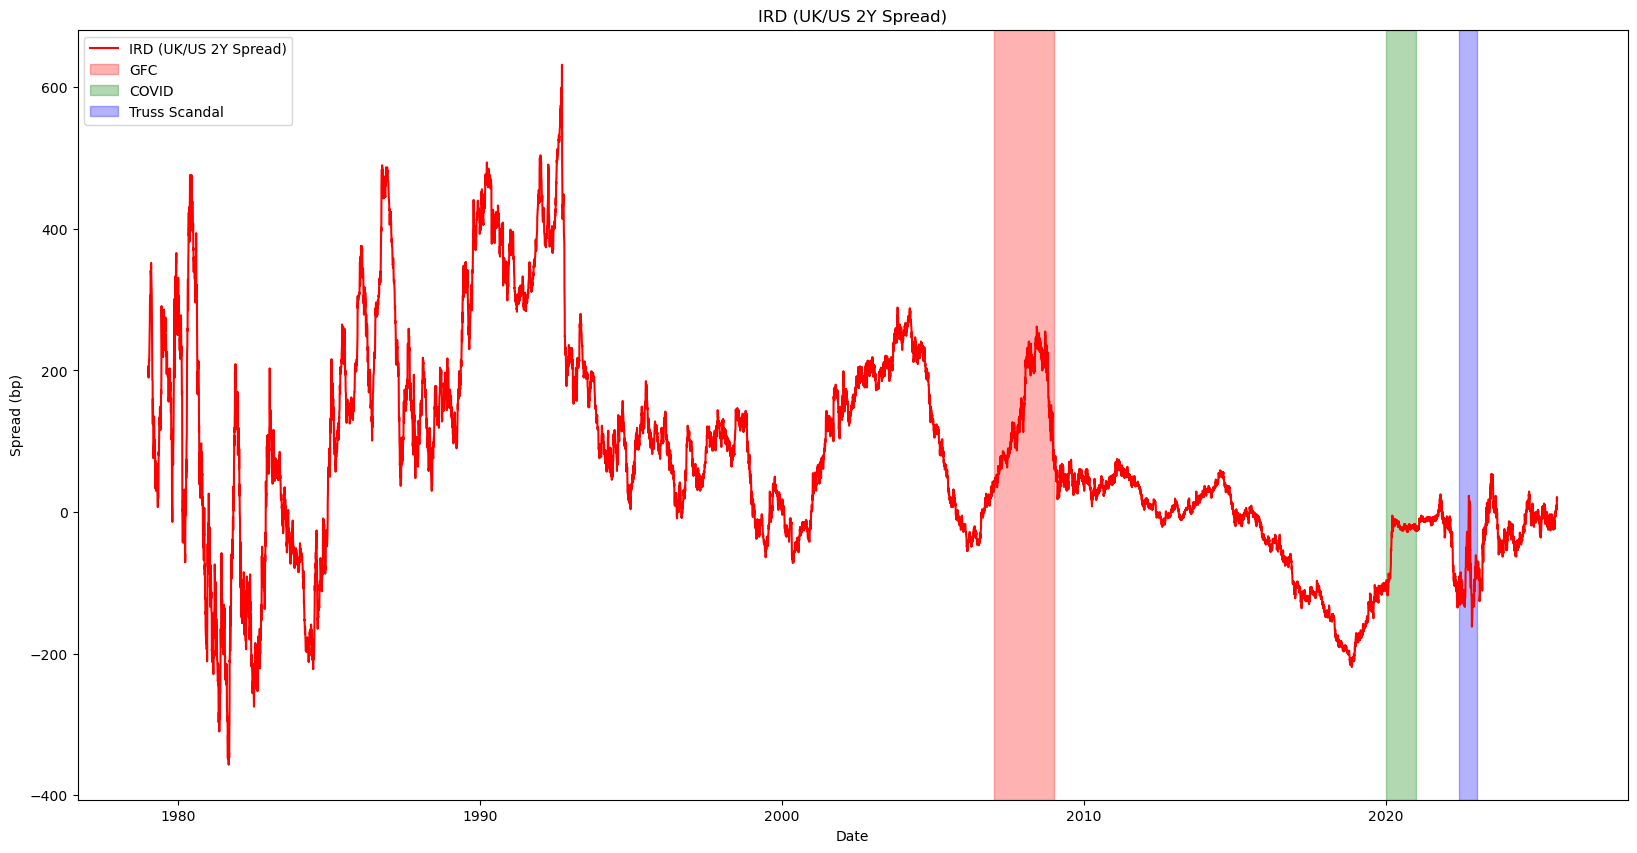

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("IRD (UK/US 2Y Spread)", fontsize=12)
axs.plot(spread["spread_bp"], label="IRD (UK/US 2Y Spread)", color="red")

# Mark GFC
start = pd.Timestamp("2007-01-01")
end = pd.Timestamp("2009-01-01")
axs.axvspan(start, end, color="red", alpha=0.3, label="GFC")

# Mark COVID
start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2021-01-01")
axs.axvspan(start, end, color="green", alpha=0.3, label="COVID")

# Mark Truss Scandal
start = pd.Timestamp("2022-06-01")
end = pd.Timestamp("2023-01-01")
axs.axvspan(start, end, color="blue", alpha=0.3, label="Truss Scandal")

axs.set_xlabel("Date")
axs.set_ylabel("Spread (bp)")
axs.legend()

## Spread vs GBP/USD Time-Series Overlay

### **Global Z-Score**

### Standardization

In [11]:
gbpusd_zscore = (gbpusd["gbp_usd_noon_rate"] - gbpusd["gbp_usd_noon_rate"].mean()) / gbpusd["gbp_usd_noon_rate"].std()
spread_zscore = (spread["spread_bp"] - spread["spread_bp"].mean()) / spread["spread_bp"].std()

### Plot

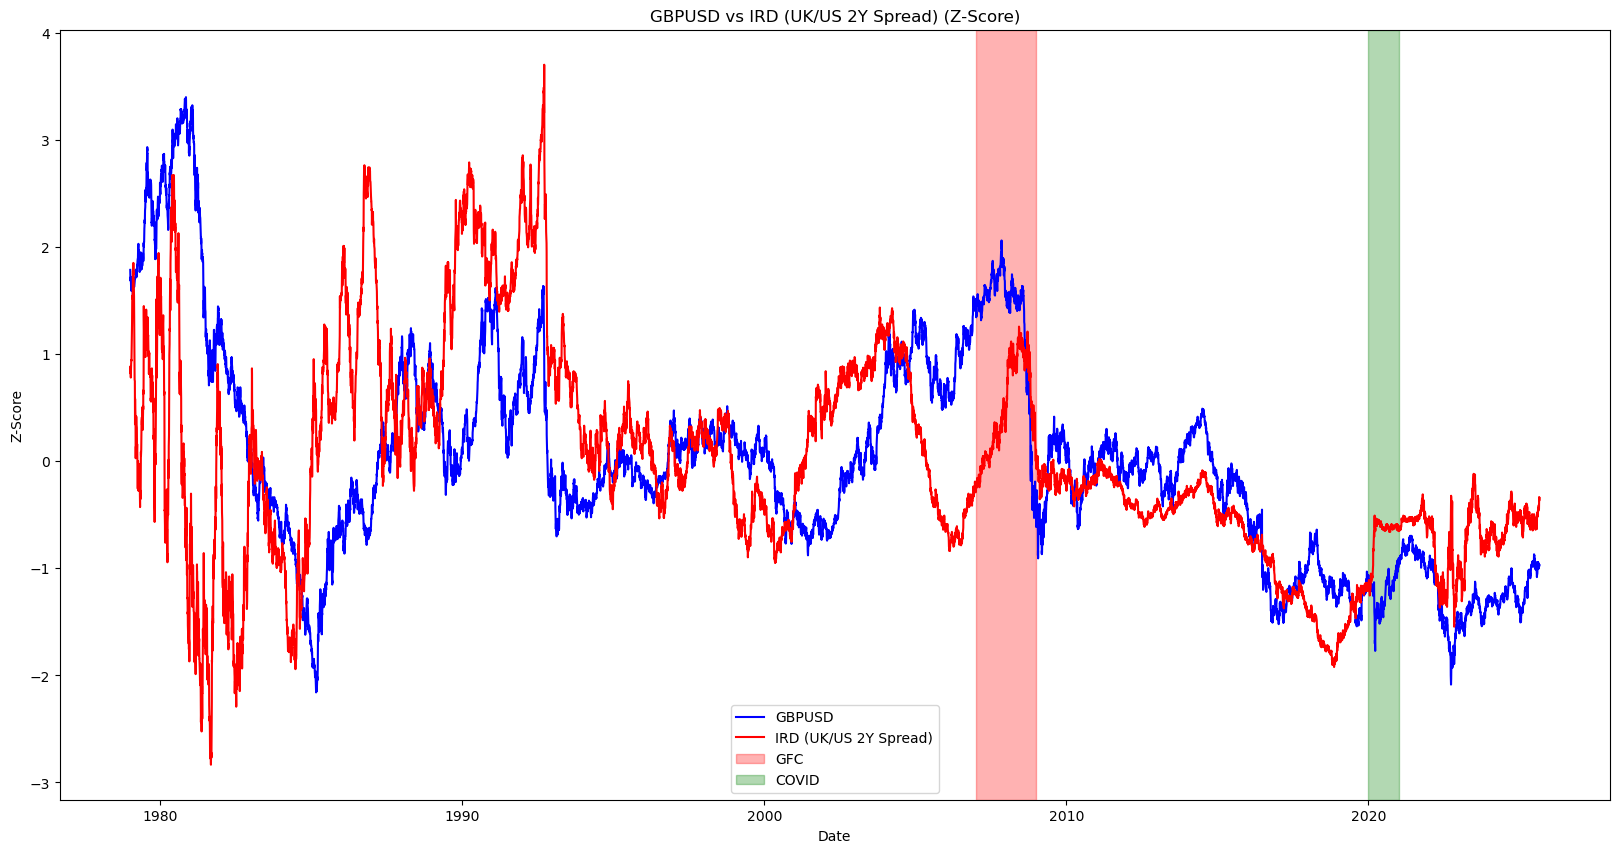

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("GBPUSD vs IRD (UK/US 2Y Spread) (Z-Score)", fontsize=12)
axs.plot(gbpusd_zscore, label="GBPUSD", color="blue")
axs.plot(spread_zscore, label="IRD (UK/US 2Y Spread)", color="red")

# Mark GFC
start = pd.Timestamp("2007-01-01")
end = pd.Timestamp("2009-01-01")
axs.axvspan(start, end, color="red", alpha=0.3, label="GFC")

# Mark COVID
start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2021-01-01")
axs.axvspan(start, end, color="green", alpha=0.3, label="COVID")

axs.set_xlabel("Date")
axs.set_ylabel("Z-Score")
axs.legend()

### Analysis

- Early signs of correlation and co-movement. Definitely related.

### **Rolling Z-Score**

### Standardization

In [13]:
window = 252 * 3
gbpusd_rolling_zscore = (gbpusd["gbp_usd_noon_rate"] - gbpusd["gbp_usd_noon_rate"].rolling(window).mean()) / gbpusd["gbp_usd_noon_rate"].rolling(window).std()
spread_rolling_zscore = (spread["spread_bp"] - spread["spread_bp"].rolling(window).mean()) / spread["spread_bp"].rolling(window).std()


### Plot

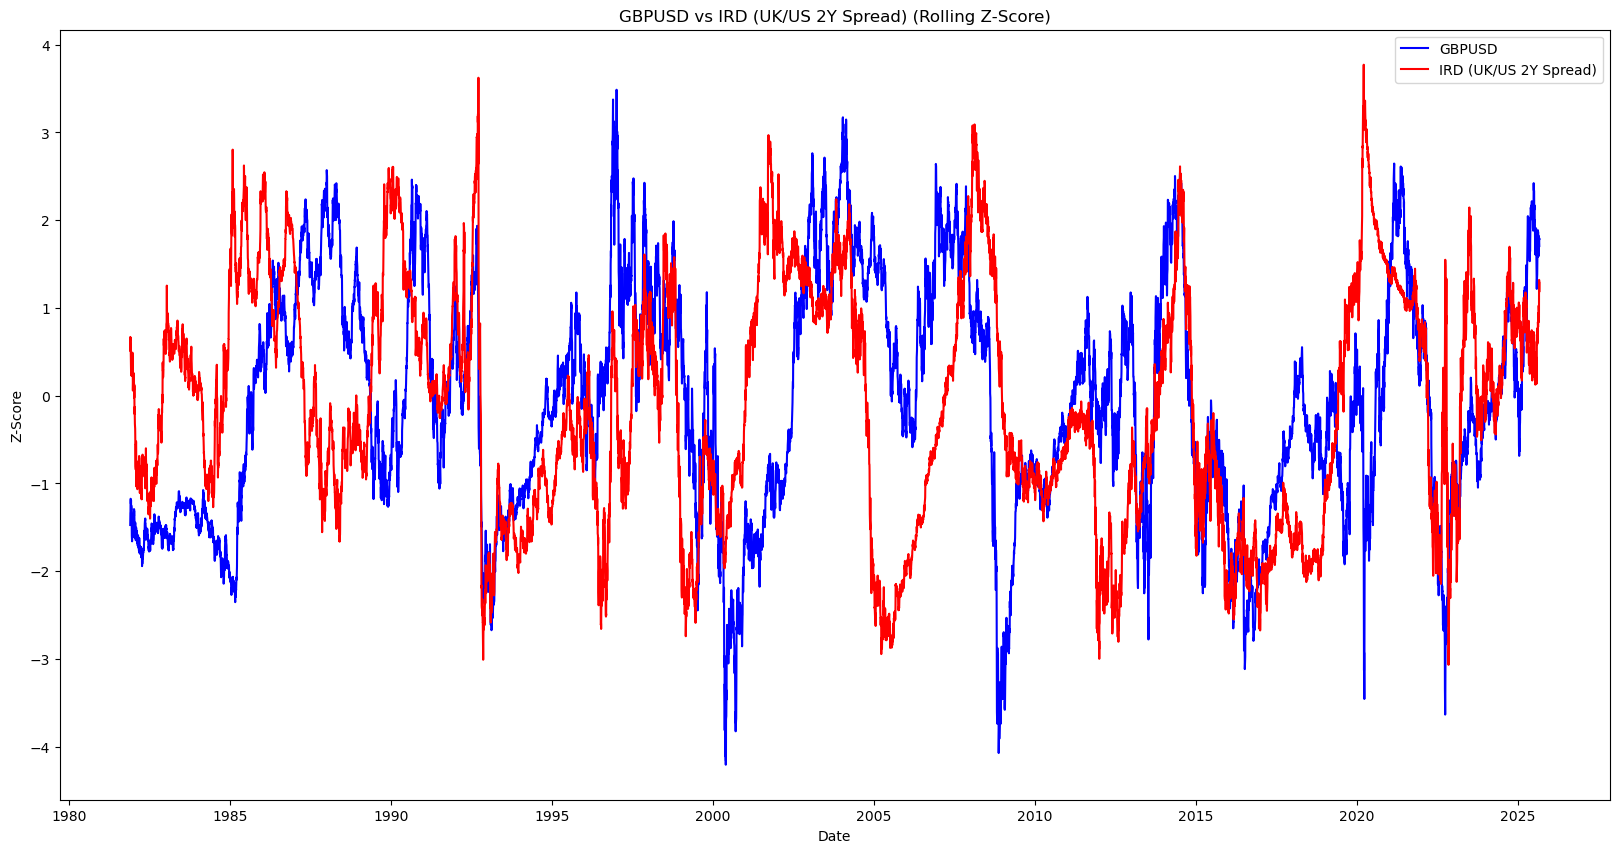

In [14]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("GBPUSD vs IRD (UK/US 2Y Spread) (Rolling Z-Score)", fontsize=12)
axs.plot(gbpusd_rolling_zscore, label="GBPUSD", color="blue")
axs.plot(spread_rolling_zscore, label="IRD (UK/US 2Y Spread)", color="red")

axs.set_xlabel("Date")
axs.set_ylabel("Z-Score")
axs.legend()

## Spread Change vs GBP/USD Returns Scatter Plot

### Plot

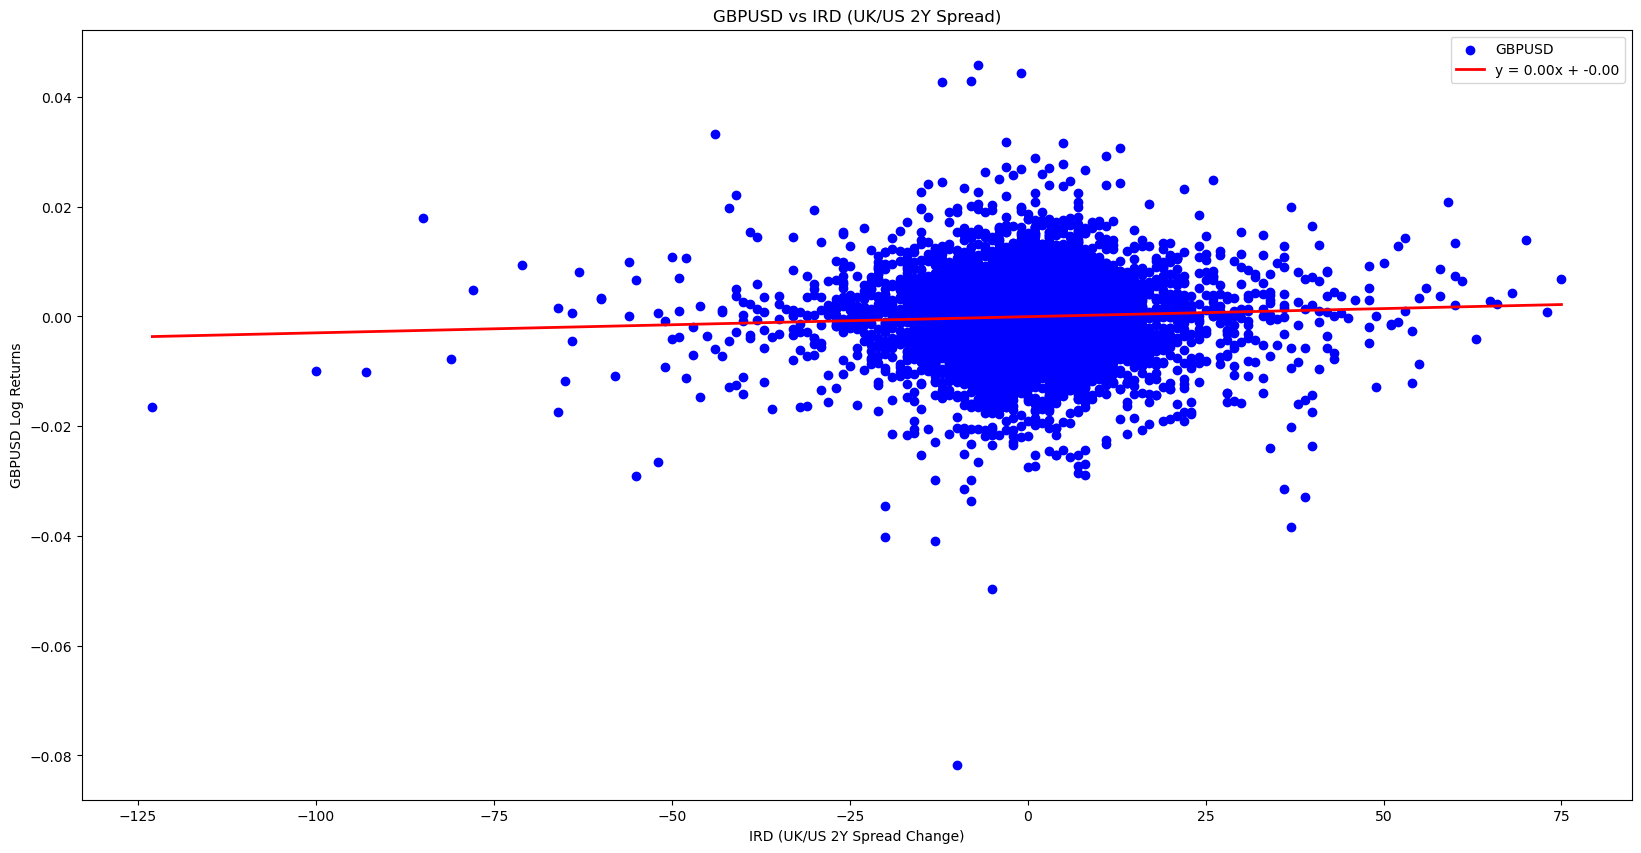

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("GBPUSD vs IRD (UK/US 2Y Spread)", fontsize=12)
axs.scatter(spread["spread_abs_change_daily"], gbpusd["log_return"], label="GBPUSD", color="blue")

slope, intercept = np.polyfit(spread["spread_abs_change_daily"].iloc[1:-1], gbpusd["log_return"].iloc[1:-1], 1)
x_line = np.linspace(min(spread["spread_abs_change_daily"].iloc[1:-1]), max(spread["spread_abs_change_daily"].iloc[1:-1]), 100)
y_line = slope * x_line + intercept
axs.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs.set_xlabel("IRD (UK/US 2Y Spread Change)")
axs.set_ylabel("GBPUSD Log Returns")
axs.legend()

### Plot Against Forward Returns

Text(0, 0.5, 'GBP/USD 30D Forward Log Returns')

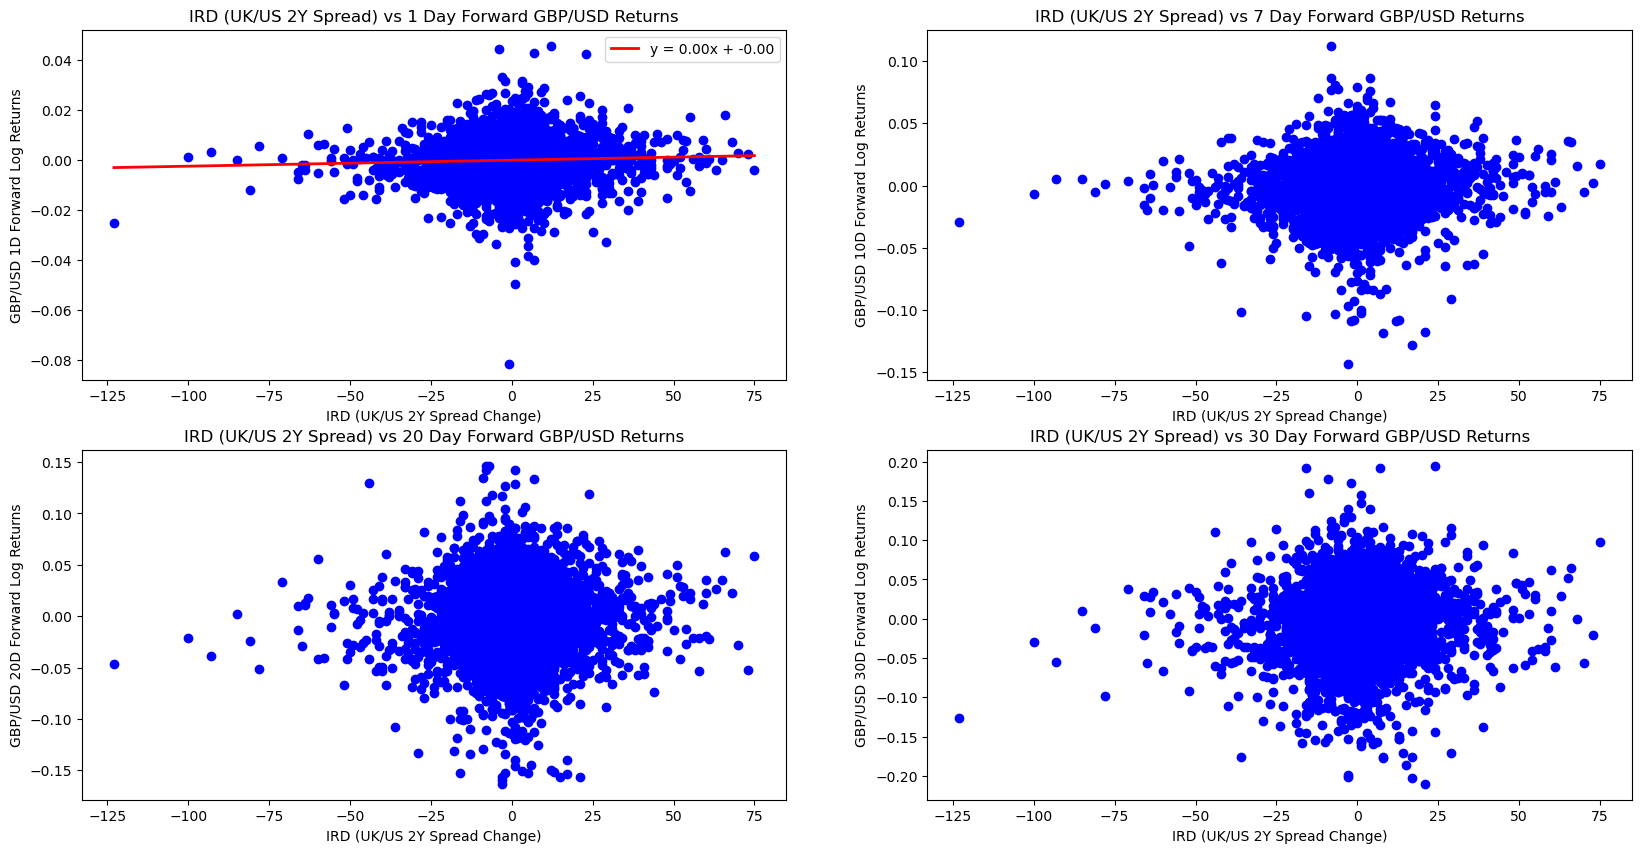

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

axs[0, 0].set_title("IRD (UK/US 2Y Spread) vs 1 Day Forward GBP/USD Returns", fontsize=12)
axs[0, 0].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-1) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[0, 0].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[0, 0].set_ylabel("GBP/USD 1D Forward Log Returns")

slope, intercept = np.polyfit(spread["spread_abs_change_daily"].iloc[1:-1], np.log(gbpusd["gbp_usd_noon_rate"].shift(-1) / gbpusd["gbp_usd_noon_rate"]).iloc[1:-1], 1)
x_line = np.linspace(min(spread["spread_abs_change_daily"].iloc[1:-1]), max(spread["spread_abs_change_daily"].iloc[1:-1]), 100)
y_line = slope * x_line + intercept
axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 0].legend()

axs[0, 1].set_title("IRD (UK/US 2Y Spread) vs 7 Day Forward GBP/USD Returns", fontsize=12)
axs[0, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-7) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[0, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[0, 1].set_ylabel("GBP/USD 10D Forward Log Returns")

axs[1, 0].set_title("IRD (UK/US 2Y Spread) vs 20 Day Forward GBP/USD Returns", fontsize=12)
axs[1, 0].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-20) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[1, 0].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[1, 0].set_ylabel("GBP/USD 20D Forward Log Returns")

axs[1, 1].set_title("IRD (UK/US 2Y Spread) vs 30 Day Forward GBP/USD Returns", fontsize=12)
axs[1, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-30) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[1, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[1, 1].set_ylabel("GBP/USD 30D Forward Log Returns")


/tmp/ipykernel_2582/1894853380.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 0].legend()


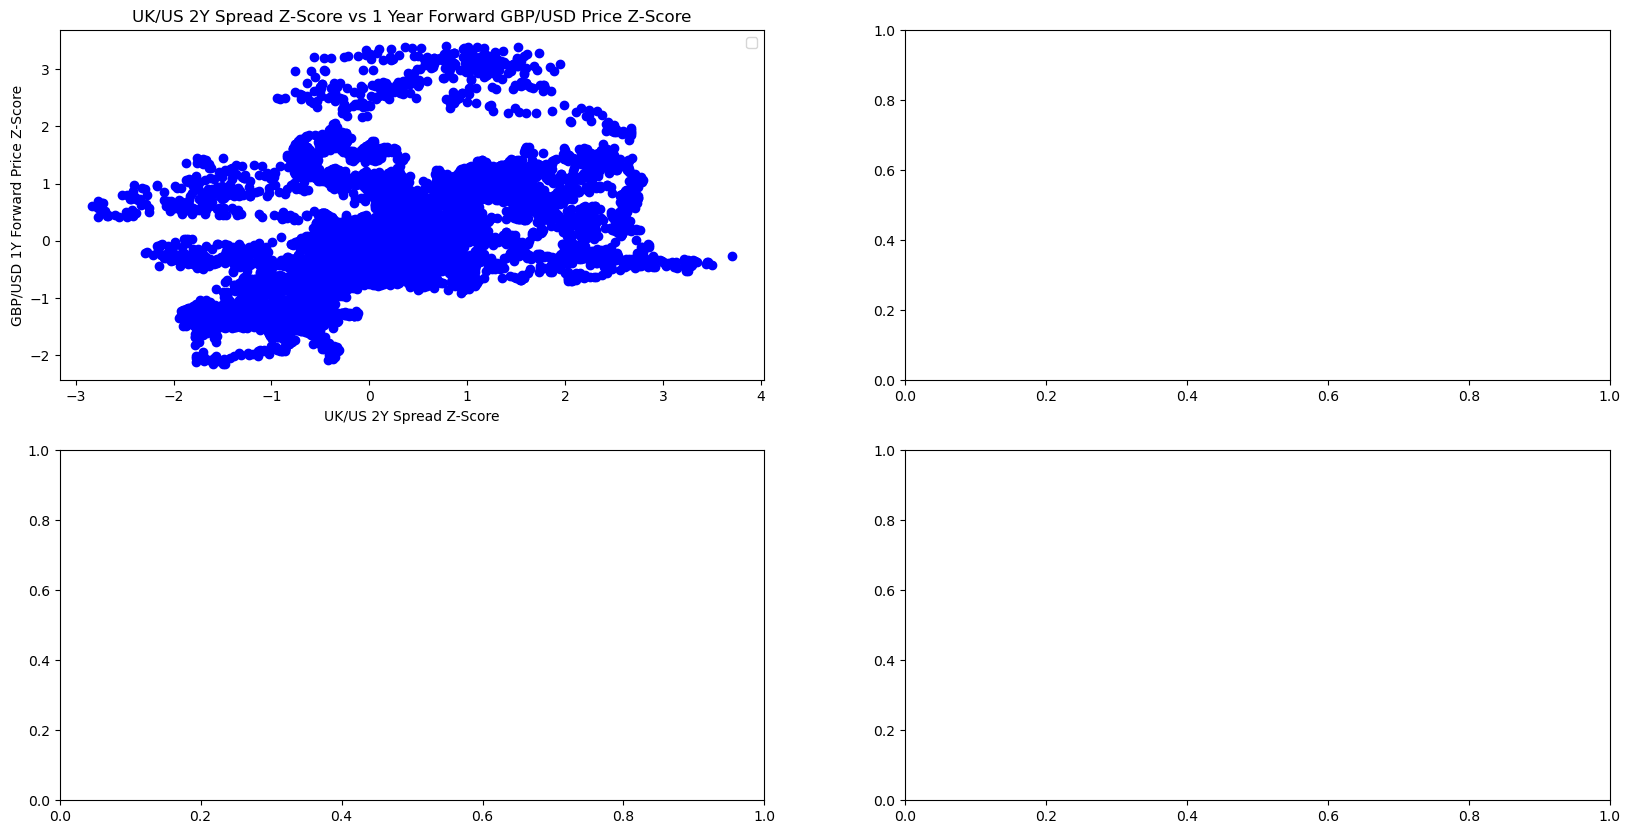

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

gbpusd_zscore.corr(spread_zscore.shift(252*2))
axs[0, 0].set_title("UK/US 2Y Spread Z-Score vs 1 Year Forward GBP/USD Price Z-Score", fontsize=12)
axs[0, 0].scatter(spread_zscore.shift(252), gbpusd_zscore, color="blue")

axs[0, 0].set_xlabel("UK/US 2Y Spread Z-Score")
axs[0, 0].set_ylabel("GBP/USD 1Y Forward Price Z-Score")

# slope, intercept = np.polyfit(spread["spread_abs_change_daily"].iloc[1:-1], np.log(gbpusd["gbp_usd_noon_rate"].shift(-1) / gbpusd["gbp_usd_noon_rate"]).iloc[1:-1], 1)
# x_line = np.linspace(min(spread["spread_abs_change_daily"].iloc[1:-1]), max(spread["spread_abs_change_daily"].iloc[1:-1]), 100)
# y_line = slope * x_line + intercept
# axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 0].legend()

# axs[0, 1].set_title("IRD (UK/US 2Y Spread) vs 7 Day Forward GBP/USD Returns", fontsize=12)
# axs[0, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-7) / gbpusd["gbp_usd_noon_rate"]), color="blue")

# axs[0, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
# axs[0, 1].set_ylabel("GBP/USD 10D Forward Log Returns")

# axs[1, 0].set_title("IRD (UK/US 2Y Spread) vs 20 Day Forward GBP/USD Returns", fontsize=12)
# axs[1, 0].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-20) / gbpusd["gbp_usd_noon_rate"]), color="blue")

# axs[1, 0].set_xlabel("IRD (UK/US 2Y Spread Change)")
# axs[1, 0].set_ylabel("GBP/USD 20D Forward Log Returns")

# axs[1, 1].set_title("IRD (UK/US 2Y Spread) vs 30 Day Forward GBP/USD Returns", fontsize=12)
# axs[1, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-30) / gbpusd["gbp_usd_noon_rate"]), color="blue")

# axs[1, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
# axs[1, 1].set_ylabel("GBP/USD 30D Forward Log Returns")


## Correlation

#### Contemporaneous

In [18]:
gbpusd_zscore.corr(spread_zscore)

np.float64(0.3743044611806594)

In [19]:
spread["spread_abs_change_daily"].corr(gbpusd["log_return"])

np.float64(0.045897507147514956)

- Correlation(Δspread, daily FX returns) ≈ 0.046 → almost no contemporaneous link in short-term changes.


- Correlation(z-scored spread level, z-scored FX price level) ≈ 0.374 → much stronger positive relationship in levels.
    - When UK 2y yields are structurally higher than US 2y yields, GBP/USD tends to trade structurally stronger.
    - About 14% of the variance in GBP/USD levels can be explained by variation in the 2y spread level, if you assume a simple linear relationship.

**Potential Explanations**
- Spreads are a slow-moving macro variable.
- FX returns are fast-moving, noisy.
- If you compare them at the wrong horizon (daily), you mostly get noise. At longer horizons (weekly/monthly), the link might reappear.


#### Lagged

**Lagged Correlation: Change in Yield Spread vs GBP/USD Returns**

In [33]:
for h in [0, 1, 5, 10, 20, 30, 60, 90, 180, 252, 252 * 2, 252 * 3, 252 * 5, 252 * 10]:
    print(f"{h} day ahead correlation: {spread["spread_abs_change_daily"].shift(h).corr(gbpusd["log_return"])}")


0 day ahead correlation: 0.045897507147514956
1 day ahead correlation: 0.03768255088939237
5 day ahead correlation: 0.008697435803764626
10 day ahead correlation: 0.01600000202612878
20 day ahead correlation: -0.007561384366650443
30 day ahead correlation: 0.0039709066491965435
60 day ahead correlation: -0.006702381950156468
90 day ahead correlation: 0.020470543705881687
180 day ahead correlation: 0.027224850309280513
252 day ahead correlation: 0.012532159217582288
504 day ahead correlation: 0.018750332209971812
756 day ahead correlation: 0.011938248243634068
1260 day ahead correlation: -0.0032390019969973437
2520 day ahead correlation: 0.001986255867956733


**Lagged Correlation: Yield Spread vs GBP/USD**

In [32]:
for h in [0, 1, 5, 10, 20, 30, 60, 90, 180, 252, 252 * 2, 252 * 3, 252 * 5, 252 * 10]:
    print(f"{h} day ahead correlation: {spread_zscore.shift(h).corr(gbpusd_zscore)}")


0 day ahead correlation: 0.3743044611806594
1 day ahead correlation: 0.3754944819051879
5 day ahead correlation: 0.37966061195784717
10 day ahead correlation: 0.3841435797197906
20 day ahead correlation: 0.39096199032936957
30 day ahead correlation: 0.39700380817550446
60 day ahead correlation: 0.4146384199285588
90 day ahead correlation: 0.4327738510362487
180 day ahead correlation: 0.4666347315763211
252 day ahead correlation: 0.46818091762094477
504 day ahead correlation: 0.4986528512993598
756 day ahead correlation: 0.49601032345663043
1260 day ahead correlation: 0.3231264261689487
2520 day ahead correlation: 0.012418231739199091


In [41]:
correlation_varying_lag_time_horizon = pd.Series(
    {h: spread_zscore.shift(h).corr(gbpusd_zscore) for h in range(0, 252*10)}
)

Text(0, 0.5, 'Correlation')

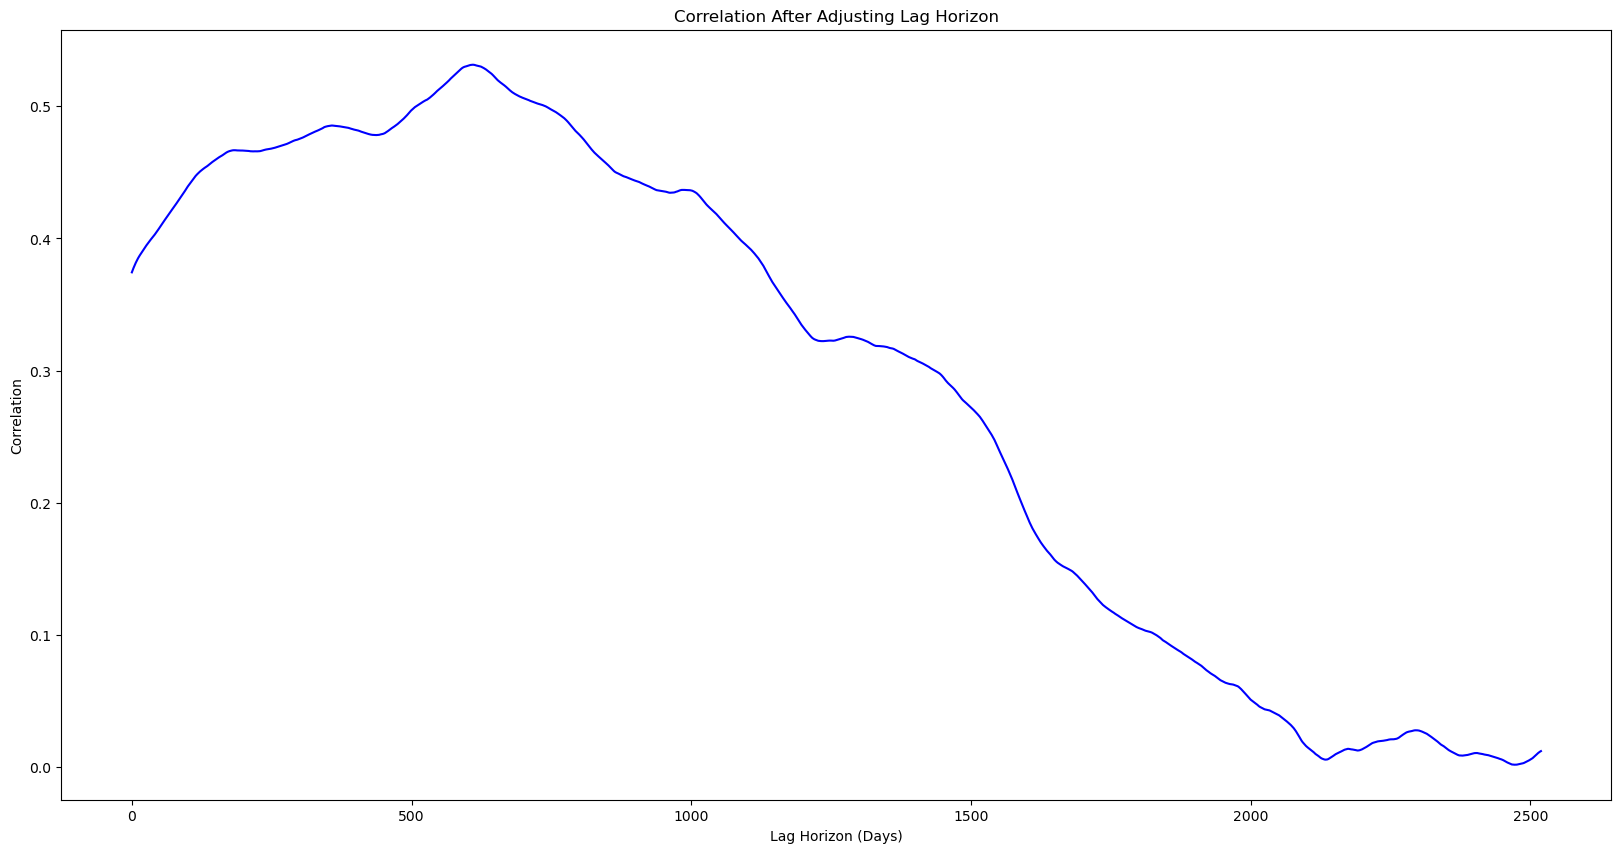

In [45]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("Correlation After Adjusting Lag Horizon", fontsize=12)
axs.plot(correlation_varying_lag_time_horizon, color="blue")

axs.set_xlabel("Lag Horizon (Days)")
axs.set_ylabel("Correlation")

#### Dynamic

Line plot would make sense here

In [25]:
spread["spread_abs_change_daily"].rolling(window=252).corr(gbpusd["log_return"]).describe()

count    11923.000000
mean         0.106851
std          0.184188
min         -0.491509
25%          0.026887
50%          0.150869
75%          0.244306
max          0.437911
dtype: float64

In [26]:
spread["spread_abs_change_daily"].shift(10).rolling(window=252).corr(gbpusd["log_return"]).describe()

count    11913.000000
mean         0.004659
std          0.068696
min         -0.190396
25%         -0.043705
50%         -0.003376
75%          0.045183
max          0.237007
dtype: float64

#### Conditionality

Binned average plot (conditional expectation plot)
What it shows: how the size of the spread signal today maps to average forward returns/levels.

How it looks:

X-axis = today’s spread level (binned into quantiles).

Y-axis = average forward FX return (or z-scored level) at a chosen horizon.

Points or bars with error bars (confidence intervals).

Use case: tests monotonicity and economic plausibility. For example: do higher spreads → systematically higher GBP returns over the next 3m, 6m, 12m?

#### Non-Linear Relationship Detection

## Next Steps

- Use weekly & monthly time horizons for Spread and FX
    - Spreads evolve relatively slowly (policy expectations don’t flip every day).
    - FX returns are very noisy day-to-day, buffeted by flows, positioning, risk sentiment, etc.
    - At the daily frequency, you’re trying to line up a slow signal with a noisy variable → correlation collapses.
    - At weekly or monthly horizons, the noise cancels out and the structural link between changes in spreads and FX might re-emerge.